# Parameter Graphs
This tutorial showcases how one can generate parameter sets, i.e., $f_1 \times f_2 \times \ldots \times f_n$ supporting each steady state. 

Then we plots the corresponding parameter graphs, i.e., 2D projections of $f_a \times f_b$ combinations. The figures won't look the same or be as beautiful as the one in the manuscript as it has been done manually in TikZ.


In [1]:
import mbnet as mn
import pandas as pd

## Toggle Switch

In [2]:
topo = '../../Inputs/Topo/TS.topo'
adjmat = mn.utils.topo_to_adj(topo)

We can get a compact form of the parameter set for each node. The MBMs supporting these states can be arrived by taking combinations for each element in the set.

In [3]:
ps = mn.tl.param_set(adjmat, explode=False)
ps

,A,B
00,{0},{0}
01,"{0, ID}","{ID, 1}"
10,"{ID, 1}","{0, ID}"
11,{1},{1}


Otherwise, one can get the longer form where each parameter combination is present.

In [4]:
ps = mn.tl.param_set(adjmat)
ps

,state,A,B
0,00,0,0
1,01,0,ID
2,01,0,1
3,01,ID,ID
4,01,ID,1
5,10,ID,0
6,10,ID,ID
7,10,1,0
8,10,1,ID
9,11,1,1


This allows for subsetting, and counting the exact number of models supporting each state.

In [5]:
len(ps[ps['state'] == '10'])

4

We can then plot this as a parameter graph. The color of the heatmap gives the multistability it supports and the individual states are mentioned in the annotation, seperated by linebreak.

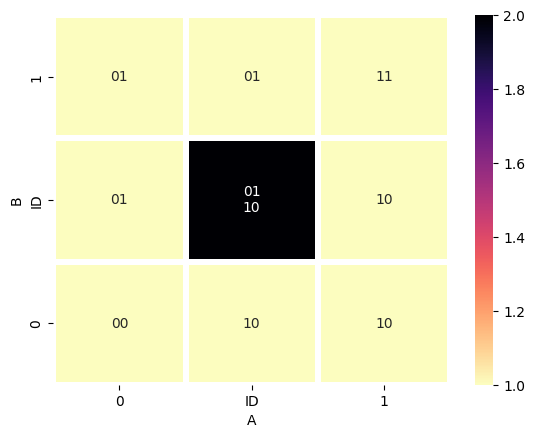

In [6]:
mn.pl.PG(ps,'A','B', (1,1))

One can also get the parameter sets that support multistability between different states.

In [7]:
states = pd.DataFrame([[1,0],[0,1]], columns=adjmat.columns)
mn.tl.multistable(adjmat, states)

,A,B
0,ID,ID


## Toggle Switch with Self-Activation

Similar exercise can be done for networks with more inputs, but the visualization becomes tricky to interpret from the discontinuity due to partial order.

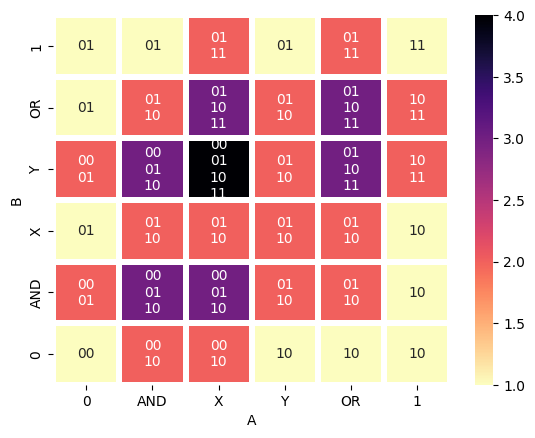

In [8]:
topo = '../../Inputs/Topo/TSSA.topo'
adjmat = mn.utils.topo_to_adj(topo)
ps = mn.tl.param_set(adjmat)
mn.pl.PG(ps,'A','B', (2,2))

In [9]:
states = pd.DataFrame([[1,0],[0,1],[0,0]], columns=adjmat.columns)
mn.tl.multistable(adjmat, states)

,A,B
0,AND,Y
1,AND,AND
2,X,Y
3,X,AND


## 2 Team network with 3 nodes

For networks with more than 2 nodes, 2D parameter graph visualization becomes challenging. The approach is to iterate over parameter values for the additional nodes, creating separate 2D projections where other node functions are held constant.

In [10]:
topo = '../../Inputs/Topo/2Team3N.topo'
adjmat = mn.utils.topo_to_adj(topo)

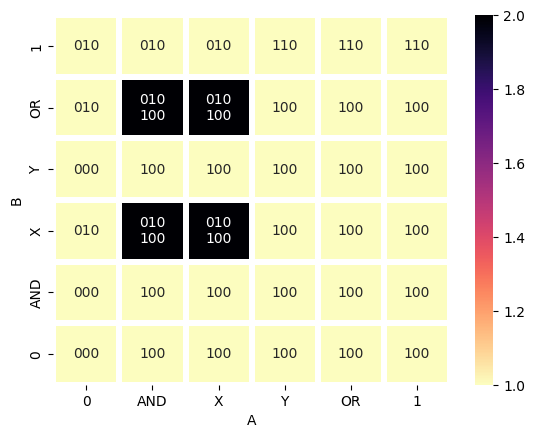

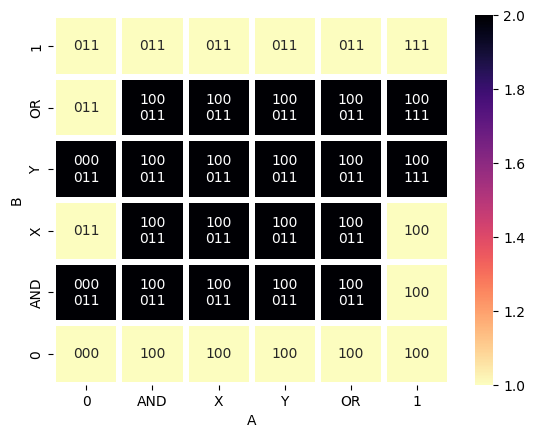

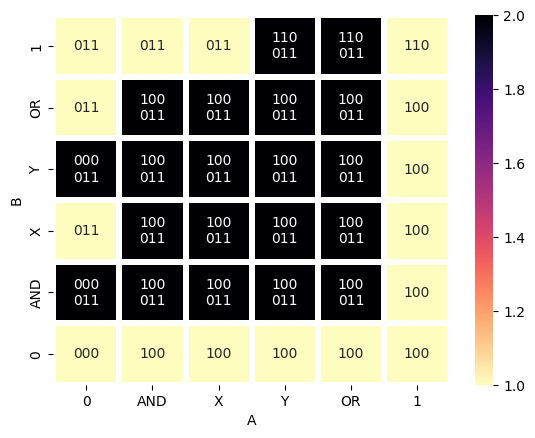

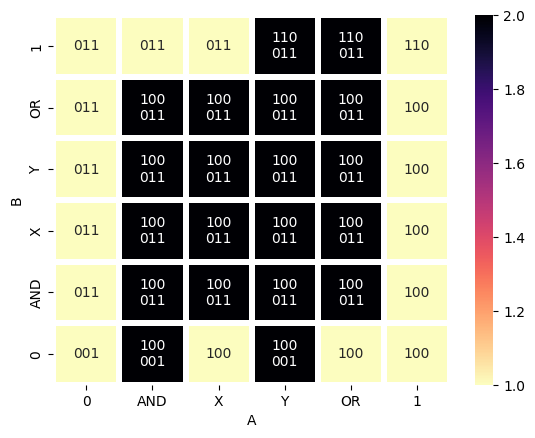

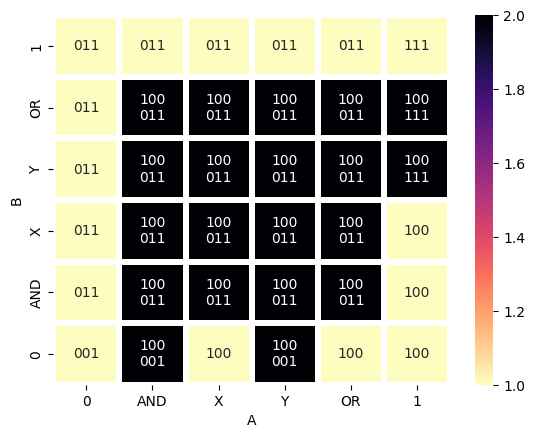

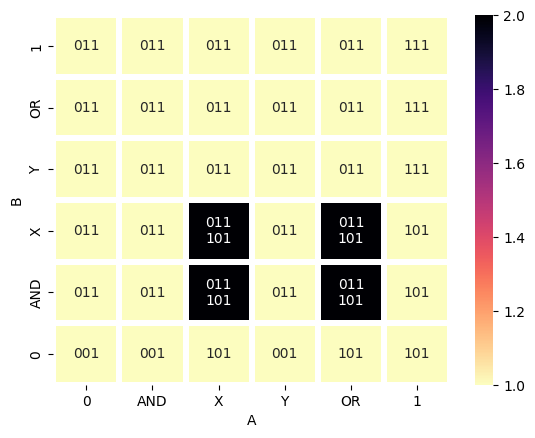

In [11]:
ps = mn.tl.param_set(adjmat)
for funC in ps.loc[:,'C'].unique():
    pssub = ps[ps.loc[:,'C'] == funC]
    mn.pl.PG(pssub,'A','B', (2,2))

In [12]:
states = pd.DataFrame([[1,0,0],[0,1,1]], columns=adjmat.columns)
len(mn.tl.multistable(adjmat, states))

64